In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path().absolute().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
from src.time_series import load_multi_csv, load_angles
from src.sliding_window import sliding_windows_multiplet
from src.inference import load_model, predict_multiplet, predict_classes_from_proba
from src.visual import plot_raw_multiplet, plot_multiplet_predictions, plot_angles
from src.criteria import process_multiplet

2026-05-05 13:53:05.744634: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


# Отображение только углов

In [3]:
data_path=str(PROJECT_ROOT)+'/time_series/TOI-1136_arg_p_max_history_resonance_3_2_between_1_and_2_original_angles.csv'
data = load_angles(data_path, ['phi_0_original', 'phi_1_original'], time_column='time_years')
# data

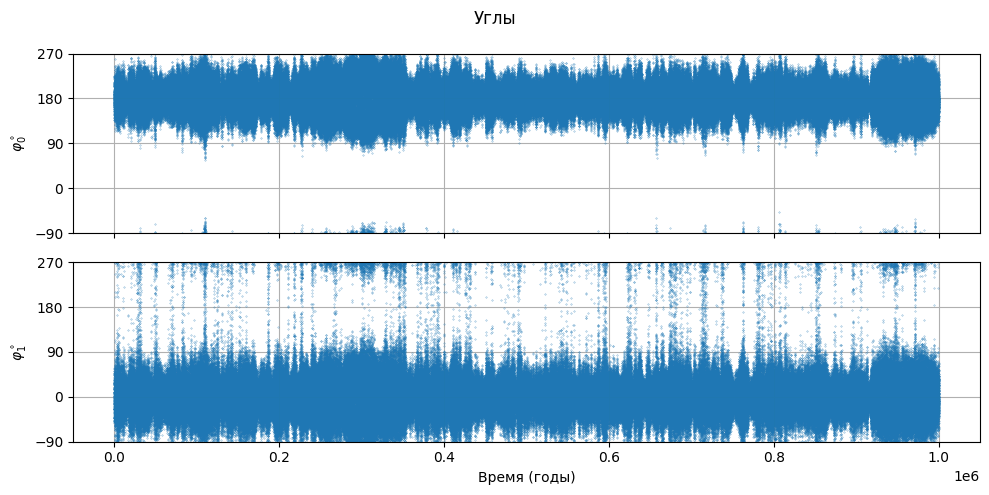

In [4]:
plot_angles(data['time_years'], data['angles_deg'], title='Углы')

# Построить мультиплет и отношения периодов (двухтельынй MMR)

In [10]:
data_path=str(PROJECT_ROOT)+'/time_series/TOI-1136_arg_p_max_history_resonance_3_2_between_1_and_2_original_angles.csv'
data = load_multi_csv(
    filepath=data_path,
    angle_columns=['phi_0_original', 'phi_1_original'],  # подставь свои имена колонок
    period_column='period_ratio',
    time_column='time_years',
    angle_unit='deg',
    convert_to_xy=True,
)

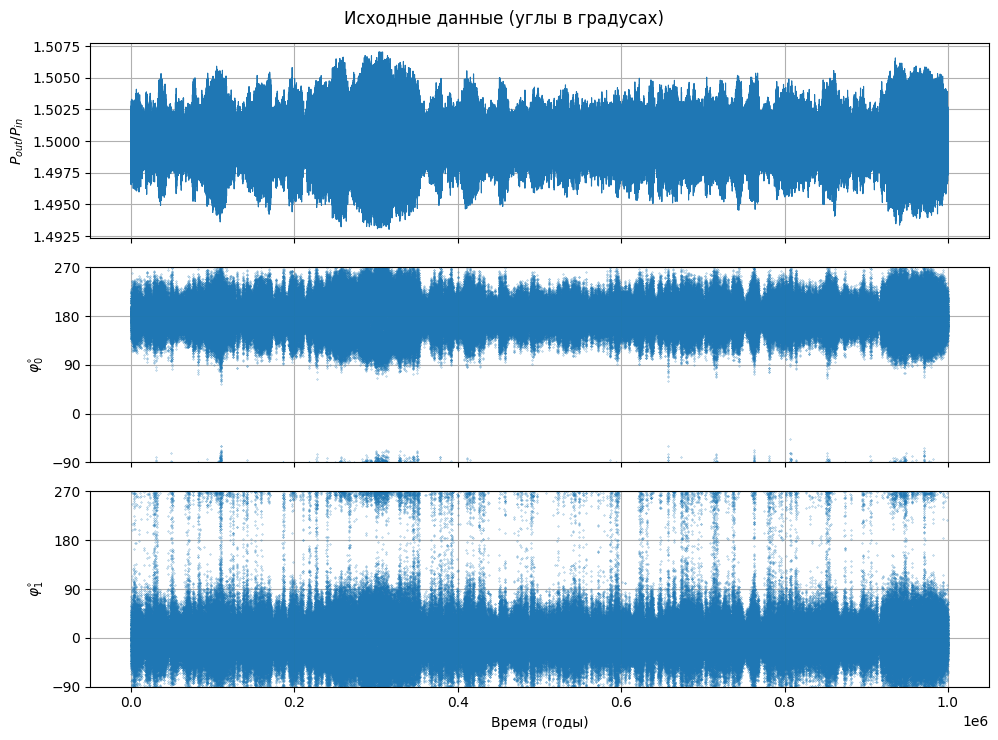

In [11]:
plot_raw_multiplet(
    time_years=data['time_years'],
    period_ratio=data['period_ratio'],
    angles_deg_list=data['angles_deg'],
    title='Исходные данные (углы в градусах)',
    angle_min=-90., #Диапазоны нормализации угла
    angle_max=270.
    # save_path=''
)

# Разбиение на окна для подачи в модель

In [6]:
# print('Ключи:', data.keys())
# print('Форма period_ratio:', data['period_ratio'].shape)
# print('Количество углов:', len(data['angles_xy']))
# print('Диапазон времени: {:.2e} – {:.2e} лет'.format(
#     data['time_years'][0], data['time_years'][-1]))

In [12]:
windows = sliding_windows_multiplet(
    data_dict=data,
    window_length=4000,
    overlap_ratio=0.
)


In [6]:
# print('Число окон:', len(windows['window_bounds']))
# print('Форма окон первого угла:', windows['angle_windows'][0].shape)
# print('Границы первого окна (индексы):', windows['window_bounds'][0])
# print('Границы последнего окна:', windows['window_bounds'][-1])

# Запрос прогнозов-меток от модели #1

In [13]:
model = load_model('1', models_dir=str(PROJECT_ROOT)+'/models/')

In [8]:
# print("Число углов:", len(windows['angle_windows']))
# for i, w in enumerate(windows['angle_windows']):
#     print(f"Угол {i}: shape = {w.shape}, dtype = {w.dtype}")

In [14]:
# from src.inference import predict_multiplet, predict_classes_from_proba

In [14]:
#Прогнозы модели
probs = predict_multiplet(windows['angle_windows'], model)
# print("Число массивов вероятностей:", len(probs))
# for i, p in enumerate(probs):
#     print(f"Угол {i}: shape = {p.shape}, dtype = {p.dtype}")
#     print(f"  Суммы вероятностей по окнам (первые 5): {p[:5].sum(axis=1)}")
#     print(f"  Диапазон значений: min={p.min():.4f}, max={p.max():.4f}")

In [15]:
classes = [predict_classes_from_proba(p) for p in probs]

# import numpy as np
# for i, cls in enumerate(classes):
#     unique, counts = np.unique(cls, return_counts=True)
#     total = len(cls)
#     print(f"\nУгол {i}:")
#     for u, c in zip(unique, counts):
#         print(f"  Класс {u}: {c} окон ({100*c/total:.1f}%)")

In [16]:
# n_windows = len(windows['window_bounds'])
# for i, cls in enumerate(classes):
#     assert len(cls) == n_windows, f"Угол {i}: классов {len(cls)}, а окон {n_windows}"
# print("OK: количество классов совпадает с количеством окон для всех углов.")

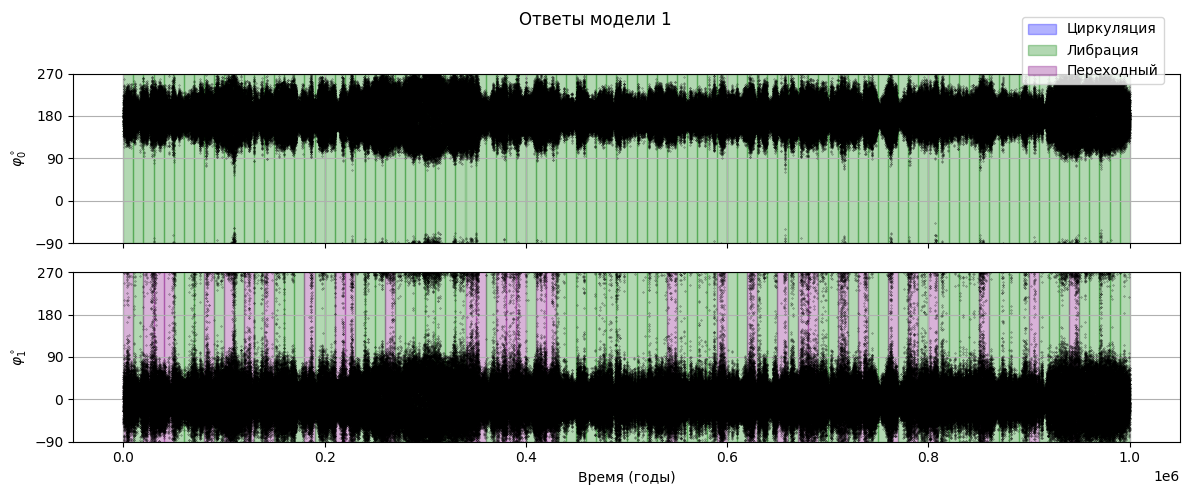

In [17]:
plot_multiplet_predictions(
    time_years=data['time_years'],
    angles_deg_list=data['angles_deg'],
    window_bounds=windows['window_bounds'],
    class_labels_list=classes,
    title='Ответы модели 1',
    angle_min=-90., #Диапазоны нормализации угла
    angle_max=270.
    # save_path='/content/drive/MyDrive/Diplom_data/resonance_sorter/notebook/predict_TOI1136_model1.png'

)

In [8]:
windows = sliding_windows_multiplet(
    data_dict=data,
    window_length=4000,
    overlap_ratio=0.
)

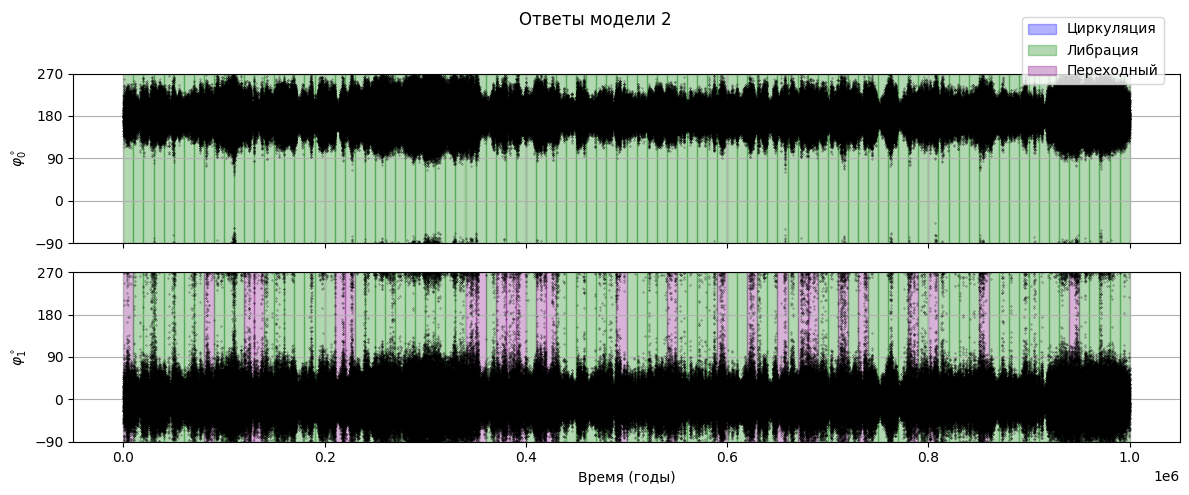

In [18]:
model = load_model('2', models_dir=str(PROJECT_ROOT)+'/models/') #Тест второй модели
probs2 = predict_multiplet(windows['angle_windows'], model)
classes2 = [predict_classes_from_proba(p) for p in probs2]
plot_multiplet_predictions(
    time_years=data['time_years'],
    angles_deg_list=data['angles_deg'],
    window_bounds=windows['window_bounds'],
    class_labels_list=classes2,
    title='Ответы модели 2',
    angle_min=-90., #Диапазоны нормализации угла
    angle_max=270.
)

In [19]:

segments = process_multiplet(
    class_labels_list=classes,
    window_bounds=windows['window_bounds'],
    time_years=data['time_years'],
    period_ratio=data['period_ratio'],
    expected_ratio=1.5,
    min_librations=30,
    max_consecutive_nonlib=2,
    sliding_window_size=6,
    max_nonlib_in_sliding=2
)

In [20]:
segments

[{'librations_count': 100,
  'start_window': 0,
  'end_window': 99,
  't_start_years': np.float32(0.0),
  't_end_years': np.float32(999997.5),
  'duration_years': np.float32(999997.5),
  'Delta_max': np.float32(0.0070397854)}]